# Computational Finance: Option Pricing Environment

## Overview
This notebook is a testing and demonstration environment for pricing options using three methods:
- **CRR Binomial Tree** (`crr_price`) — lattice-based, works for European and American options
- **Monte Carlo Simulation** (`mc_price`) — simulation-based, works for path-dependent options
- **Black-Scholes** (`bls_price`) — closed-form, European vanilla options only

All pricers accept an `Option` object, keeping the interface consistent across methods.

---

## Contents
1. Imports & shared parameters
2. European call — CRR vs Black-Scholes vs Monte Carlo
3. European put — put-call parity check
4. American put — early exercise premium
5. Digital (cash-or-nothing) call
6. Asset-or-nothing call
7. Down-and-out barrier call — CRR vs Monte Carlo
8. Up-and-out barrier call
9. Double knock-out call
10. Fixed strike lookback call (minimum)
11. Arithmetic floating-strike Asian call
12. American put via Longstaff–Schwartz (LSM)
13. CRR convergence to Black-Scholes


---
## 1. Imports & Shared Parameters

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from Option import Option
from Utilities import crr_price, bls_price, mc_price, mc_price_american_lsm
from process import GBM

### Shared model parameters

| Symbol | Value | Meaning |
|--------|-------|---------|
| `S0` | 197.2 | Current underlying spot price |
| `K` | 200 | Strike price (slightly out-of-the-money call) |
| `r` | 0.0 | Continuous risk-free rate |
| `sigma` | 0.1566 | Annualised volatility |
| `T` | 1 | Time to expiry (years) |
| `M` | 20 000 | CRR time steps (high → near-exact) |
| `Nsim` | 1 000 000 | Monte Carlo paths |

The **GBM process** object encapsulates all market parameters and is shared across every Monte Carlo call,
so each pricer uses identical paths.


In [2]:
# Shared model parameters used throughout the notebook
S0    = 197.2        # spot price
K     = 200          # strike price
r     = 0.05          # risk-free rate
sigma = 0.15658214   # annualised volatility
T     = 1            # time to expiry (years)
M     = 20000        # CRR time steps
Nsim  = int(1e6)     # MC simulations (1e6 for production, 1e5 for speed)

# GBM process — shared across all MC calls in this notebook
process = GBM(S0=S0, r=r, sigma=sigma, T=T)

---
## 2. European Call — CRR vs Black-Scholes vs Monte Carlo

### Theory

A **European call** gives the holder the right (not the obligation) to *buy* the underlying at
strike $K$ at maturity $T$.  Its payoff is:

$$C_T = \max(S_T - K,\; 0)$$

### Black-Scholes closed form

Under GBM with constant volatility $\sigma$ and risk-free rate $r$:

$$C_0 = S_0\,N(d_1) - K\,e^{-rT}\,N(d_2)$$

where

$$d_1 = \frac{\ln(S_0/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and $N(\cdot)$ is the standard normal CDF.

### Convergence check

All three pricers should agree closely:
- **Black-Scholes** is exact (under its assumptions).
- **CRR** converges to Black-Scholes as $M \to \infty$.
- **Monte Carlo** converges as $N_{\text{sim}} \to \infty$.

The control variate used in MC is the **forward price** $S_0 e^{rT}$,
which has a known analytical expectation and is strongly correlated with call payoffs,
reducing variance substantially.


In [3]:
opt = Option.eu_call(K)
opt.control_price = process.S0  # E^Q[S_T] = S0 * exp(r*T)

crr_p          = crr_price(opt, r=r, T=T, M=M, sigma=sigma, S0=S0)
bls_p          = bls_price(opt, S0=S0, r=r, T=T, sigma=sigma)
mc_p, mc_ci    = mc_price(opt, process, Nsim=Nsim)

print(f"Black-Scholes : {bls_p:.6f}")
print(f"CRR           : {crr_p:.6f}  (error vs BLS: {abs(crr_p - bls_p):.2e})")
print(f"Monte Carlo   : {mc_p:.6f}  95% CI: ({mc_ci[0]:.4f}, {mc_ci[1]:.4f})")

Black-Scholes : 15.881724
CRR           : 15.881831  (error vs BLS: 1.08e-04)
Monte Carlo   : 15.898452  95% CI: (15.8811, 15.9158)


---
## 3. European Put — Put-Call Parity Check

### Theory

A **European put** gives the right to *sell* the underlying at $K$.  Its payoff is:

$$P_T = \max(K - S_T,\; 0)$$

### Put-Call Parity

For European options on a non-dividend-paying asset:

$$C - P = S_0 - K\,e^{-rT}$$

This is a **model-free** identity; any violation implies a riskless arbitrage opportunity.
We verify it holds across all three pricers.

> **Note (r = 0 case):** When the risk-free rate is zero, $e^{-rT} = 1$, so parity simplifies to
> $C - P = S_0 - K = 197.2 - 200 = -2.8$.


In [4]:
opt_put = Option.eu_put(K)
opt_put.control_price = process.forward()

crr_put       = crr_price(opt_put, r=r, T=T, M=M, sigma=sigma, S0=S0)
bls_put       = bls_price(opt_put, S0=S0, r=r, T=T, sigma=sigma)
mc_put, _     = mc_price(opt_put, process, Nsim=Nsim)

parity = S0 - K * np.exp(-r * T)  # theoretical C - P

print(f"Put prices  — BLS: {bls_put:.4f} | CRR: {crr_put:.4f} | MC: {mc_put:.4f}")
print(f"Call prices — BLS: {bls_p:.4f}  | CRR: {crr_p:.4f}  | MC: {mc_p:.4f}")
print(f"\nPut-call parity (C - P = S0 - K*e^(-rT) = {parity:.4f})")
print(f"  BLS: {bls_p - bls_put:.4f} | CRR: {crr_p - crr_put:.4f} | MC: {mc_p - mc_put:.4f}")

Put prices  — BLS: 8.9276 | CRR: 8.9277 | MC: 8.9367
Call prices — BLS: 15.8817  | CRR: 15.8818  | MC: 15.8985

Put-call parity (C - P = S0 - K*e^(-rT) = 6.9541)
  BLS: 6.9541 | CRR: 6.9541 | MC: 6.9617


---
## 4. American Put — Early Exercise Premium

### Theory

An **American put** can be exercised *at any time* $t \in [0, T]$.
This means the holder will exercise early whenever the immediate payoff exceeds the
continuation value of holding the option.

$$V_t^{\text{Am}} = \max\!\bigl(\max(K - S_t, 0),\; \mathbb{E}^Q[e^{-r\,dt} V_{t+dt} \mid S_t]\bigr)$$

### Early Exercise Premium

$$\text{EEP} = V_0^{\text{Am}} - V_0^{\text{Eu}} \geq 0$$

For puts on a non-dividend-paying stock with $r = 0$, the early exercise premium is **zero**:
there is no benefit to exercising early because delaying always gives more time value.
Mathematically, when $r = 0$ the discounted stock price is a martingale,
so holding the put is always weakly better than exercising.

> When $r > 0$, early exercise becomes valuable because the opportunity cost of not receiving $K$
> immediately (and investing it at rate $r$) can outweigh the insurance value of waiting.


In [5]:
opt_am_put = Option.american_put(K)

crr_am = crr_price(opt_am_put, r=r, T=T, M=M, sigma=sigma, S0=S0)

print(f"European put (CRR) : {crr_put:.6f}")
print(f"American put (CRR) : {crr_am:.6f}")
print(f"Early exercise premium : {crr_am - crr_put:.6f}")

European put (CRR) : 8.927716
American put (CRR) : 10.158155
Early exercise premium : 1.230439


---
## 5. Digital (Cash-or-Nothing) Call

### Theory

A **digital call** (also called a *cash-or-nothing call*) pays a fixed amount (\$1 by convention)
if and only if $S_T > K$ at maturity; otherwise it pays nothing:

$$\text{Payoff} = \mathbf{1}_{S_T > K}$$

### Black-Scholes closed form

$$\text{Digital Call}_0 = e^{-rT}\,N(d_2)$$

where $d_2 = d_1 - \sigma\sqrt{T}$ (same as in the vanilla call formula).

### Intuition

The digital call price is essentially the **risk-neutral probability** (discounted) that the
option ends in-the-money: $e^{-rT} \cdot \mathbb{Q}(S_T > K)$.

### Relationship to vanilla call

A vanilla call can be decomposed as:

$$C = \underbrace{S_0\,N(d_1)}_{\text{asset-or-nothing}} - \underbrace{K\,e^{-rT}\,N(d_2)}_{K \times \text{digital call}}$$

This is the **call = asset-or-nothing − K × digital** decomposition explored in Section 6.


In [6]:
opt_dig = Option.eu_digital_call(K)
opt_dig.control_price = process.forward()

crr_dig           = crr_price(opt_dig, r=r, T=T, M=M, sigma=sigma, S0=S0)
bls_dig           = bls_price(opt_dig, S0=S0, r=r, T=T, sigma=sigma)
mc_dig, mc_dig_ci = mc_price(opt_dig, process, Nsim=Nsim)

print(f"Digital call — BLS: {bls_dig:.6f} | CRR: {crr_dig:.6f} | MC: {mc_dig:.6f}")
print(f"MC 95% CI: ({mc_dig_ci[0]:.4f}, {mc_dig_ci[1]:.4f})")

Digital call — BLS: 0.532696 | CRR: 0.531991 | MC: 0.532655
MC 95% CI: (0.5321, 0.5332)


---
## 6. Asset-or-Nothing Call

### Theory

An **asset-or-nothing call** pays the *asset price itself* $S_T$ if $S_T > K$, and zero otherwise:

$$\text{Payoff} = S_T \cdot \mathbf{1}_{S_T > K}$$

### Black-Scholes closed form

$$\text{Asset-or-Nothing}_0 = S_0\,N(d_1)$$

### Decomposition identity

The vanilla call decomposes as:

$$C = \underbrace{\text{Asset-or-Nothing}}_{\displaystyle S_0\,N(d_1)} - K\,e^{-rT} \cdot \underbrace{\text{Digital Call}}_{\displaystyle e^{-rT}N(d_2) \text{ before disc.}}$$

This is verified numerically below: `AoN − K * digital ≈ vanilla call`.


In [7]:
opt_aon = Option.eu_asset_or_nothing(K)
opt_aon.control_price = process.forward()

crr_aon       = crr_price(opt_aon, r=r, T=T, M=M, sigma=sigma, S0=S0)
bls_aon       = bls_price(opt_aon, S0=S0, r=r, T=T, sigma=sigma)
mc_aon, _     = mc_price(opt_aon, process, Nsim=Nsim)

print(f"Asset-or-nothing — BLS: {bls_aon:.6f} | CRR: {crr_aon:.6f} | MC: {mc_aon:.6f}")
print(f"\nDecomposition check (call = AoN - K*digital):")
print(f"  {bls_aon:.4f} - {K * bls_dig:.4f} = {bls_aon - K * bls_dig:.4f}  (BLS call = {bls_p:.4f})")

Asset-or-nothing — BLS: 122.420861 | CRR: 122.280008 | MC: 122.366381

Decomposition check (call = AoN - K*digital):
  122.4209 - 106.5391 = 15.8817  (BLS call = 15.8817)


---
## 7. Down-and-Out Barrier Call — CRR vs Monte Carlo

### Theory

A **down-and-out call** behaves like a vanilla call, but is *knocked out* (becomes worthless) if the
underlying price ever touches or falls below the barrier $B$ during $[0, T]$:

$$\text{Payoff} = \max(S_T - K,\; 0) \cdot \mathbf{1}_{\min_{0 \le t \le T} S_t > B}$$

### Why no Black-Scholes here?

A continuous-monitoring Black-Scholes formula for barrier options does exist, but our pricer
uses **discrete monitoring** (weekly: $M_{\text{monitor}} = 52$ steps), so we compare only CRR and MC.

With discrete monitoring, the barrier is only checked at the observation dates,
so the option is worth *more* than its continuous-monitoring counterpart
(fewer chances to knock out).

### Barrier discount

The down-and-out call is always worth **less than** the vanilla call:
$$\text{DAO Call} \leq \text{Vanilla Call}$$

The difference is the **barrier discount**, reflecting the probability of knock-out.


In [8]:
B   = 180   # down barrier
Monitoring_step = 52  # weekly monitoring steps

opt_dao = Option.eu_down_and_out_call(K, B)
opt_dao.control_price = process.forward()

# CRR uses the full tree (M=20000) but only checks the barrier at monitoring dates
crr_dao           = crr_price(opt_dao, r=r, T=T, M=M, sigma=sigma, S0=S0, monitoring_steps=Monitoring_step)
mc_dao, mc_dao_ci = mc_price(opt_dao, process, Nsim=Nsim, M=Monitoring_step)

print(f"Down-and-out call (B={B})")
print(f"  CRR : {crr_dao:.6f}")
print(f"  MC  : {mc_dao:.6f}  95% CI: ({mc_dao_ci[0]:.4f}, {mc_dao_ci[1]:.4f})")
print(f"\nVanilla call for reference: {bls_p:.6f}")
print(f"Barrier discount          : {bls_p - mc_dao:.6f}")

Down-and-out call (B=180)
  CRR : 14.522267
  MC  : 14.508304  95% CI: (14.4870, 14.5296)

Vanilla call for reference: 15.881724
Barrier discount          : 1.373419


---
## 8. Up-and-Out Barrier Call

### Theory

An **up-and-out call** is knocked out if the underlying *rises above* the barrier $B_{\text{up}}$:

$$\text{Payoff} = \max(S_T - K,\; 0) \cdot \mathbf{1}_{\max_{0 \le t \le T} S_t < B_{\text{up}}}$$

### Key intuitions

- When $B_{\text{up}}$ is close to $S_0$, the option has **little value** — most paths quickly breach
  the upper barrier, knocking the option out before it can pay anything.
- When $B_{\text{up}}$ is very far above $S_0$, the up-and-out call approaches the vanilla call price
  (the barrier rarely matters).
- Unlike the down-and-out call, increasing volatility can *decrease* the up-and-out call's value
  because higher volatility means a greater chance of breaching the upper barrier.

With our parameters: $S_0 = 197.2$, $B_{\text{up}} = 220$, $K = 200$.
The barrier is only $\approx 11.6\%$ above spot, so most paths that become in-the-money will
also breach $B_{\text{up}}$, resulting in a very low price.


In [9]:
B_up = 220  # up barrier

opt_uao = Option.eu_up_and_out_call(K, B_up)
opt_uao.control_price = process.forward()

crr_uao        = crr_price(opt_uao, r=r, T=T, M=M, sigma=sigma, S0=S0, monitoring_steps=Monitoring_step)
mc_uao, uao_ci = mc_price(opt_uao, process, Nsim=Nsim, M=Monitoring_step)

print(f"Up-and-out call (B_up={B_up})")
print(f"  CRR : {crr_uao:.6f}")
print(f"  MC  : {mc_uao:.6f}  95% CI: ({uao_ci[0]:.4f}, {uao_ci[1]:.4f})")

Up-and-out call (B_up=220)
  CRR : 0.753544
  MC  : 0.758917  95% CI: (0.7535, 0.7643)


---
## 9. Double Knock-Out Call

### Theory

A **double knock-out call** is knocked out if the underlying ever leaves the corridor $(B_{\text{low}},\, B_{\text{high}})$:

$$\text{Payoff} = \max(S_T - K,\; 0) \cdot \mathbf{1}_{B_{\text{low}} < \min S_t \text{ and } \max S_t < B_{\text{high}}}$$

This is the most restrictive barrier type — *only paths that remain entirely inside the corridor survive*.

### Barrier hierarchy (CRR prices)

| Option | Price |
|--------|-------|
| Vanilla | ~11.04 |
| Down-and-out (B=180) | ~9.95 |
| Up-and-out (B=220) | ~0.71 |
| Double knock-out (180, 220) | ~0.41 |

The double knock-out is always worth *less* than either single-barrier version because it adds an
extra knock-out condition.


In [10]:
B_low  = 180
B_high = 220

opt_dko = Option.eu_double_knock_out_call(K, B_low, B_high)
opt_dko.control_price = process.forward()

crr_dko        = crr_price(opt_dko, r=r, T=T, M=M, sigma=sigma, S0=S0, monitoring_steps=Monitoring_step)
mc_dko, dko_ci = mc_price(opt_dko, process, Nsim=Nsim, M=Monitoring_step)

print(f"Double knock-out call (B_low={B_low}, B_high={B_high})")
print(f"  CRR : {crr_dko:.6f}")
print(f"  MC  : {mc_dko:.6f}  95% CI: ({dko_ci[0]:.4f}, {dko_ci[1]:.4f})")
print(f"\nBarrier summary (CRR prices):")
print(f"  Vanilla      : {crr_p:.4f}")
print(f"  Down-and-out : {crr_dao:.4f}")
print(f"  Up-and-out   : {crr_uao:.4f}")
print(f"  Double KO    : {crr_dko:.4f}")

Double knock-out call (B_low=180, B_high=220)
  CRR : 0.434173
  MC  : 0.441350  95% CI: (0.4371, 0.4456)

Barrier summary (CRR prices):
  Vanilla      : 15.8818
  Down-and-out : 14.5223
  Up-and-out   : 0.7535
  Double KO    : 0.4342


---
## 10. Fixed Strike Lookback Call (Minimum)

### Theory

A **fixed-strike lookback call** is a path-dependent option whose payoff depends on the
**minimum price** reached by the underlying over the entire path:

$$\text{Payoff} = \max(S_{\min} - K,\; 0), \qquad S_{\min} = \min_{0 \le t \le T} S_t$$

The holder can "look back" over the life of the option and exercise based on the most favorable
(lowest) asset price — making it especially valuable in volatile markets.

### Key properties

- **Path-dependent**: requires the full price trajectory (MC only; no CRR support).
- More expensive than a vanilla call with the same strike (the effective "strike" is the minimum,
  which is always ≤ $S_T$).
- No control variate: no simple analytical formula for the lookback payoff expectation.

### Pricing note

With $K = 170$ (below $S_0 = 197.2$), the option is already deeply in-the-money at inception
in the sense that $S_0 > K$, so virtually every path contributes a positive payoff.


In [11]:
# Create the fixed-strike lookback call option (minimum-based)
lb_min_call_option = Option.fixed_strike_lookback_call_min(K=170)
# No control variate for lookback options

# Price the option using Monte Carlo simulation
mc_lb_call, lb_call_ci = mc_price(lb_min_call_option, process, Nsim=Nsim, M=Monitoring_step)

# Print results
print("Fixed Strike Lookback Call (Minimum) Pricing:")
print(f"Monte Carlo Price: {mc_lb_call:.6f}")
print(f"95% Confidence Interval: ({lb_call_ci[0]:.6f}, {lb_call_ci[1]:.6f})")

Fixed Strike Lookback Call (Minimum) Pricing:
Monte Carlo Price: 12.055037
95% Confidence Interval: (12.036382, 12.073693)


---
## 11. Arithmetic Floating-Strike Asian Call

### Theory

An **Asian option** has a payoff that depends on the **average price** of the underlying over
the option's life, rather than just the terminal price.

For the **arithmetic floating-strike Asian call**, the strike *is* the path average:

$$\text{Payoff} = \max\!\left(S_T - \bar{S},\; 0\right)$$

where the discrete arithmetic average is:

$$\bar{S} = \frac{1}{M}\sum_{i=1}^{M} S_{t_i}$$

### Key properties

| Feature | Asian (floating strike) | European call |
|---------|------------------------|---------------|
| Strike | Path average $\bar{S}$ | Fixed $K$ |
| Path-dependent | Yes | No |
| Volatility sensitivity | **Lower** | Higher |
| Payoff | $\max(S_T - \bar{S}, 0)$ | $\max(S_T - K, 0)$ |

### Intuition

- The holder profits only if the **final price beats the average** — a weaker condition than beating
  a fixed strike.
- Because $\bar{S}$ and $S_T$ are correlated, the net payoff $S_T - \bar{S}$ has lower variance than
  $S_T - K$, making Asian options **cheaper** (and more amenable to sellers).
- Widely used in **commodity** and **energy** markets where price manipulation near expiry is a concern.

### Why no control variate?

The geometric Asian call has a closed-form formula and can serve as a control variate for the
*geometric* floating strike Asian call. However, for the *arithmetic* floating-strike version
the geometric control variate payoffs are not directly comparable (different averaging),
so no CV is applied here.


In [12]:
# Create the Arithmetic floating strike Asian call option
afs_asian_call_option = Option.arithmetic_floating_strike_asian_call()
# No control variate for floating-strike Asian (geometric Asian CV doesn't apply here)

# Price the option using Monte Carlo simulation
mc_afs_call, afs_call_ci = mc_price(afs_asian_call_option, process, Nsim=Nsim, M=Monitoring_step)

# Print results
print("Arithmetic floating strike Asian call Pricing:")
print(f"Monte Carlo Price: {mc_afs_call:.6f}")
print(f"95% Confidence Interval: ({afs_call_ci[0]:.6f}, {afs_call_ci[1]:.6f})")

Arithmetic floating strike Asian call Pricing:
Monte Carlo Price: 9.526705
95% Confidence Interval: (9.501357, 9.552053)


---
## 12. American Put via Longstaff–Schwartz (LSM)

### Motivation

American options can be exercised early.  The CRR tree handles early exercise naturally via
backward induction.  For **Monte Carlo**, we need a way to estimate the *continuation value*
at each time step — this is the Longstaff–Schwartz (LSM) algorithm (2001).

---

### Algorithm

#### Step 1 — Simulate paths (forward pass)

Generate $N$ risk-neutral GBM paths:
$$S_0 \to S_1 \to \cdots \to S_M$$

#### Step 2 — Terminal payoff

At $T = M \cdot \Delta t$:
$$V_M = \text{payoff}(S_M)$$

#### Step 3 — Backward induction

For $t = M-1, M-2, \ldots, 1$:

**(a)** Identify **in-the-money (ITM)** paths: those where immediate exercise is possible.

**(b)** Regress the discounted future value $Y = V_{t+1} \cdot e^{-r\Delta t}$ on basis functions of $S_t$:

$$A = \begin{bmatrix} 1 & S_t & S_t^2 \end{bmatrix}, \qquad \hat{\alpha} = \arg\min \|A\alpha - Y\|^2$$

Estimated continuation value: $\hat{C}(S_t) = A\hat{\alpha}$

**(c)** **Exercise decision** (ITM paths only):

$$V_t = \begin{cases} \text{payoff}(S_t) & \text{if } \text{payoff}(S_t) > \hat{C}(S_t) \\ \hat{C}(S_t) & \text{otherwise} \end{cases}$$

Non-ITM paths: $V_t \leftarrow V_{t+1} \cdot e^{-r\Delta t}$

#### Step 4 — Final discount

$$V_0 = V_1 \cdot e^{-r\Delta t}$$

#### Output

$$\hat{V}_0 = \frac{1}{N}\sum_{i=1}^N V_0^{(i)}, \qquad \text{95\% CI: } \hat{V}_0 \pm 1.96\frac{\hat{\sigma}}{\sqrt{N}}$$

---

### Key insight

> LSM turns the American pricing problem into:  
> **"Learn the continuation value by regression, then compare with immediate exercise."**

The polynomial basis $\{1,\, S_t,\, S_t^2\}$ is simple and works well in practice.
Extensions use Laguerre polynomials, neural networks (Deep LSM), or more complex bases.

---

### Comparison with CRR

| Method | Handles early exercise? | Works for path-dependent? | Accuracy |
|--------|------------------------|--------------------------|----------|
| CRR binomial tree | ✅ | ❌ | Very high (large $M$) |
| LSM (Monte Carlo) | ✅ | ✅ | Good (large $N$, $M$) |

---

### Recall: r = 0 → EEP = 0

As established in Section 4, with $r = 0$ there is no early exercise premium for American puts
on non-dividend-paying stocks.  LSM should confirm this: its price should match the European put.


In [17]:
opt_am_put_lsm = Option.american_put(K)

# LSM needs many steps to approximate the continuous early-exercise boundary
M_lsm = 50
lsm_price, lsm_ci = mc_price_american_lsm(opt_am_put_lsm, process, Nsim=Nsim, M=M_lsm)

print("American put — Longstaff-Schwartz (LSM)")
print(f"  LSM price      : {lsm_price:.6f}  95% CI: ({lsm_ci[0]:.4f}, {lsm_ci[1]:.4f})")
print(f"  American CRR put   : {crr_am:.6f}  (CRR reference)")
print(f"  European put   : {mc_put:.6f}  (MC reference)")
print(f"  EEP (LSM-MC)  : {lsm_price - mc_put:.6f}  (expected ≈ 0 when r=0)")
print(f"   CRR-MC  : {crr_am - lsm_price:.6f}  (expected ≈ 0 )")


American put — Longstaff-Schwartz (LSM)
  LSM price      : 10.089160  95% CI: (10.0671, 10.1112)
  American CRR put   : 10.158155  (CRR reference)
  European put   : 8.936743  (MC reference)
  EEP (LSM-MC)  : 1.152417  (expected ≈ 0 when r=0)
   CRR-MC  : 0.068995  (expected ≈ 0 )


---
## 13. CRR Convergence to Black-Scholes

### Theory

The CRR (Cox-Ross-Rubinstein) binomial tree converges to the Black-Scholes price as $M \to \infty$.

The up/down factors are parameterised as:
$$u = e^{\sigma\sqrt{\Delta t}}, \qquad d = \frac{1}{u}, \qquad \Delta t = \frac{T}{M}$$

The risk-neutral probability is:
$$\pi = \frac{e^{r\Delta t} - d}{u - d}$$

As $M \to \infty$, the binomial distribution of log-returns converges (by CLT) to
the Normal distribution assumed by Black-Scholes.

### Convergence rate

The CRR tree oscillates around the Black-Scholes price as $M$ increases, with the error
decreasing at roughly $O(1/M)$.  The log-log plot of absolute error should be approximately
linear with slope $\approx -1$.

We plot both **price convergence** (left) and **absolute error on a log-log scale** (right).


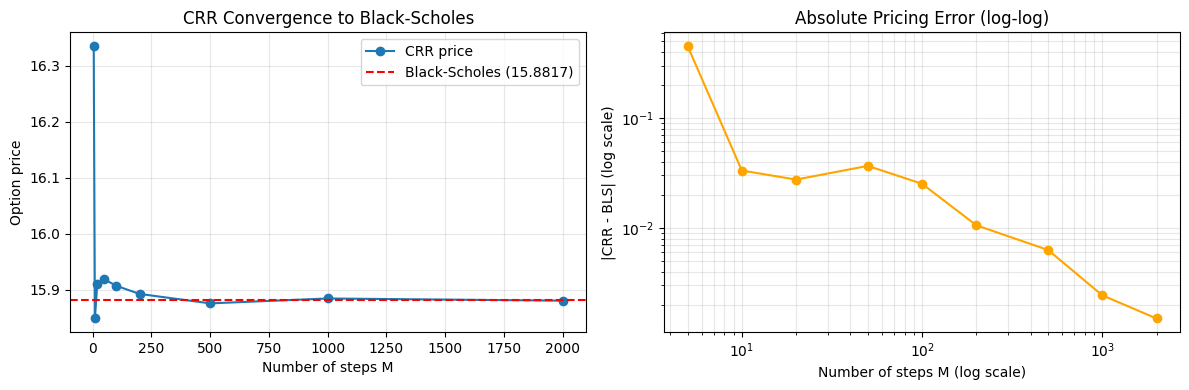

Black-Scholes reference: 15.881724
CRR at M=2000           : 15.880226  (error: 1.50e-03)


In [14]:
opt_conv = Option.eu_call(K)
bls_ref  = bls_price(opt_conv, S0=S0, r=r, T=T, sigma=sigma)

steps      = [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
crr_prices = [crr_price(opt_conv, r=r, T=T, M=m, sigma=sigma, S0=S0) for m in steps]
errors     = [abs(p - bls_ref) for p in crr_prices]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: price convergence
axes[0].plot(steps, crr_prices, 'o-', label='CRR price')
axes[0].axhline(bls_ref, color='red', linestyle='--', label=f'Black-Scholes ({bls_ref:.4f})')
axes[0].set_xlabel('Number of steps M')
axes[0].set_ylabel('Option price')
axes[0].set_title('CRR Convergence to Black-Scholes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: absolute error on log scale
axes[1].loglog(steps, errors, 'o-', color='orange')
axes[1].set_xlabel('Number of steps M (log scale)')
axes[1].set_ylabel('|CRR - BLS| (log scale)')
axes[1].set_title('Absolute Pricing Error (log-log)')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"Black-Scholes reference: {bls_ref:.6f}")
print(f"CRR at M=2000           : {crr_prices[-1]:.6f}  (error: {errors[-1]:.2e})")

---
---

# Computational Finance: Process Simulation Environment

## Overview

This section is a dedicated environment for simulating and studying **stochastic processes** used
in quantitative finance. Each process model makes different assumptions about how asset prices evolve,
and each captures different market phenomena (fat tails, jumps, stochastic volatility, etc.).

All implementations are built from a common `Process` abstract base class with a single
`simulate(Nsim, M, antithetic)` interface, so any process can be plugged directly into `mc_price`.

---

## Roadmap

### 1. Foundational Processes
- **Standard Brownian Motion** — Gaussian increments, continuous paths, the bedrock of GBM
- **Poisson Process** — counts of random events; foundation for jump models

---

### 2. Finite Activity Jump-Diffusions
These models augment GBM with a finite (Poisson-intensity) number of jumps per unit time.

- **Merton (1976)** — log-normal jumps; closed-form European option price
- **Kou (2002)** — double-exponential jumps; analytical tractability, better tail fit

---

### 3. Random Time Subordinators
These are non-decreasing processes used to "re-time" Brownian motion, creating fat tails and skew.

- **Gamma Process** — the canonical business-time clock; infinite activity, finite variation
- **Inverse Gaussian (IG) Process** — the first-passage time of BM; heavier tails than Gamma

---

### 4. Infinite Activity Lévy Models
These subordinate Brownian motion through a random clock, creating infinitely many small jumps.

- **Variance Gamma (VG)** — GBM time-changed by a Gamma process; skew and excess kurtosis
- **Normal Inverse Gaussian (NIG)** — GBM time-changed by an IG process; semi-heavy tails

---

### 5. Stochastic Volatility
In these models, volatility itself is random, capturing the **volatility smile/skew** observed in markets.

- **Heston (1993)** — CIR mean-reverting variance; correlation between spot and variance (leverage effect)
  - Simulated via Euler–Maruyama discretisation of the coupled SDEs

---

## Notes
- Each subsection will include **theoretical background**, the SDE or characteristic function, and a **Python implementation**.
- Path visualisations will be shown alongside statistical summaries.
- The goal is to build intuition alongside technical implementation.
